# Modelo 2 — Clasificador OCT con segmentación previa

In [1]:
pip install segmentation_models_pytorch

In [2]:
import os
import numpy as np
import kagglehub
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
from PIL import Image


# Setea la carpeta data como default para almacenar los datasets descargados
os.environ["KAGGLEHUB_CACHE"] = "./data"

# ── Rutas ──────────────────────────────────────────────────────────────
path_clas = os.path.abspath('./data/datasets/paultimothymooney/kermany2018')
dir_kaggle_clas = 'paultimothymooney/kermany2018'

if os.access(path_clas, os.F_OK) is False:
    path = kagglehub.dataset_download(dir_kaggle_clas)
    path_clas = os.path.abspath(path)
else:
    print('El dataset ya ha sido descargado previamente.')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAIN_PATH  =  Path(os.path.join(path_clas,"versions/2/OCT2017 /train"))
VAL_PATH   = Path(os.path.join(path_clas,"versions/2/OCT2017 /val"))
TEST_PATH   = Path(os.path.join(path_clas,"versions/2/OCT2017 /test"))

print(f"Ruta de las imágenes TRAIN: {TRAIN_PATH}")
print(f"Ruta de las imágenes VAL: {VAL_PATH}")
print(f"Ruta de las imágenes TEST: {TEST_PATH}")



100%|██████████| 10.8G/10.8G [01:50<00:00, 106MB/s]

Extracting files...


Ruta de las imágenes TRAIN: /content/data/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train
Ruta de las imágenes VAL: /content/data/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /val
Ruta de las imágenes TEST: /content/data/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test


In [3]:
!ls -R /content/modelos
import os
print(os.path.exists("/content/modelos/unetpp_smp_finetunning.pth"))
print(os.path.getsize("/content/modelos/unetpp_smp_finetunning.pth"))


/content/modelos:
unetpp_smp_finetunning.pth
True
104507999


In [4]:
# ── Carga del modelo de segmentación ──────────────────────────────────
# El modelo es UNet++ con encoder ResNet34, 1 canal entrada, 8 clases de salida.
# Guardado con torch.save(model.state_dict(), ...)

seg_model = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights=None,   # no cargar imagenet, vamos a cargar nuestros pesos
    in_channels=1,
    classes=8
)
import gdown

gdown.download(id='1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp',
               output='modelos/unetpp_smp_finetunning.pth',
               quiet=False)

import os
size = os.path.getsize('modelos/unetpp_smp_finetunning.pth')
print(f"{size / 1024 / 1024:.1f} MB")  # debe decir ~99.6 MB

seg_model.load_state_dict(torch.load('/content/modelos/unetpp_smp_finetunning.pth', map_location=device))
seg_model.to(device)
seg_model.eval()

# Congelar: no queremos que se entrene junto con el clasificador
for param in seg_model.parameters():
    param.requires_grad = False

print('Modelo de segmentación cargado y congelado.')

Downloading...
From (original): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp
From (redirected): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp&confirm=t&uuid=3f21d152-fc59-49d2-b400-2601f22814cb
To: /content/modelos/unetpp_smp_finetunning.pth
100%|██████████| 105M/105M [00:01<00:00, 96.6MB/s]


99.7 MB
Modelo de segmentación cargado y congelado.


In [5]:
# ── Dataset con segmentación on-the-fly ───────────────────────────────
# Pipeline por imagen:
#   1. Cargar imagen OCT (RGB desde ImageFolder)
#   2. Convertir a escala de grises (1 canal) → pasar por seg_model
#   3. La máscara resultante (valores 0-7) se normaliza a [0,1] y se
#      repite en 3 canales para que sea compatible con ResNet50
#   4. Aplicar normalización ImageNet
from torch.utils.data import Subset
class SegmentedDataset(Dataset):
    def __init__(self, folder_path, seg_model, augment=False):
        self.base_ds   = datasets.ImageFolder(folder_path)
        self.seg_model = seg_model
        self.augment   = augment
        self.classes   = self.base_ds.classes

        # Pre-procesado para el modelo de segmentación
        # UNet++ espera (1, H, W) normalizado [0,1]
        self.to_seg = transforms.Compose([
            transforms.Resize((224, 512)),   # mismo tamaño usado en entrenamiento del segmentador
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),           # [0,1]
        ])

        # Post-procesado: la máscara se normaliza y pasa a 3 canales
        self.post = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
        ]) if augment else nn.Identity()

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img_pil, label = self.base_ds.imgs[idx]
        img_pil = Image.open(img_pil).convert('RGB')

        # 1. Preparar input para segmentador (escala de grises, 1 canal)
        x_seg = self.to_seg(img_pil).unsqueeze(0).to(device)  # (1,1,H,W)

        # 2. Inferencia del segmentador → máscara (H,W) con valores 0-7
        with torch.no_grad():
            logits = self.seg_model(x_seg)           # (1,8,H,W)
            mask   = logits.argmax(dim=1).squeeze(0) # (H,W)

        # 3. Normalizar máscara a [0,1] y expandir a 3 canales
        mask_f = mask.float() / 7.0                  # (H,W) en [0,1]
        mask_3c = mask_f.unsqueeze(0).repeat(3,1,1)  # (3,H,W)

        # 4. Augmentación + normalización ImageNet
        mask_3c = self.aug(mask_3c)
        mask_3c = self.post(mask_3c)

        return mask_3c.cpu(), label


train_ds = SegmentedDataset(TRAIN_PATH, seg_model, augment=True)
val_ds   = SegmentedDataset(VAL_PATH,   seg_model, augment=False)
test_ds  = SegmentedDataset(TEST_PATH,  seg_model, augment=False)

indices_train = np.random.choice(len(train_ds), 2000, replace=False)


# num_workers=0 porque el segmentador corre en GPU/CPU principal
train_loader = DataLoader(Subset(train_ds, indices_train), batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0)

print(f'Train: {len(indices_train)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Clases: {train_ds.classes}')

Train: 83484 | Val: 32 | Test: 968
Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [6]:
# ── Modelo clasificador ───────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)   # CNV, DME, DRUSEN, NORMAL
model.to(device)

# ── Loss + optimizer ──────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
# ── Train loop ────────────────────────────────────────────────────────
from tqdm import tqdm

epochs     = 20
patience   = 5
best_val   = float('inf')
bad_epochs = 0

os.makedirs('modelos', exist_ok=True)
best_path = 'modelos/modelo2_seg_resnet50.pth'

for epoch in range(epochs):

    # ── train ──
    model.train()
    train_loss = 0.0

    for x, y in tqdm(train_loader, desc=f'Epoch {epoch+1} train'):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── val ──
    model.eval()
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            val_loss    += loss_fn(logits, y).item()
            val_correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_loader.dataset)

    print(f'Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}')

    # ── early stopping ──
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
        print(f'  ✅ Mejoró val_loss. Guardado en {best_path}')
    else:
        bad_epochs += 1
        print(f'  ⏳ No mejoró. patience: {bad_epochs}/{patience}')

        if bad_epochs >= patience:
            print(f'🛑 Early stopping: {patience} épocas sin mejora.')
            break

print('Entrenamiento finalizado.')

Epoch 1 train: 100%|██████████| 125/125 [01:18<00:00,  1.60it/s]


Epoch 1/20 - train loss: 0.9912 - val loss: 1.0003 - val acc: 0.5312
  ✅ Mejoró val_loss. Guardado en modelos/modelo2_seg_resnet50.pth


Epoch 2 train: 100%|██████████| 125/125 [01:09<00:00,  1.81it/s]


Epoch 2/20 - train loss: 0.7123 - val loss: 1.0931 - val acc: 0.5938
  ⏳ No mejoró. patience: 1/5


Epoch 3 train: 100%|██████████| 125/125 [01:06<00:00,  1.87it/s]


...

Epoch 15/20 - train loss: 0.1433 - val loss: 1.0091 - val acc: 0.6875
  ⏳ No mejoró. patience: 3/5


Epoch 16 train: 100%|██████████| 125/125 [01:06<00:00,  1.88it/s]


Epoch 16/20 - train loss: 0.1459 - val loss: 1.0318 - val acc: 0.7188
  ⏳ No mejoró. patience: 4/5


Epoch 17 train: 100%|██████████| 125/125 [01:05<00:00,  1.90it/s]


Epoch 17/20 - train loss: 0.1074 - val loss: 0.7533 - val acc: 0.8438
  ⏳ No mejoró. patience: 5/5
🛑 Early stopping: 5 épocas sin mejora.
Entrenamiento finalizado.


              precision    recall  f1-score   support

         CNV       0.82      0.91      0.86       242
         DME       0.87      0.74      0.80       242
      DRUSEN       0.83      0.69      0.75       242
      NORMAL       0.77      0.93      0.84       242

    accuracy                           0.82       968
   macro avg       0.82      0.82      0.82       968
weighted avg       0.82      0.82      0.82       968



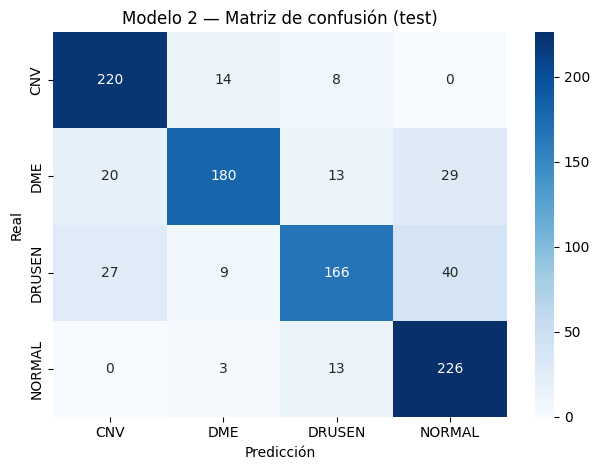

In [8]:
# ── Evaluación en test ────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model(x).argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Modelo 2 — Matriz de confusión (test)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()